In [2]:
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# System and OS related tasks
import sys
import os

# Add the project root to Python path
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

# path to directories
raw_dir = '../data/raw'
processed_dir = '../data/processed'

# 1.0 Load All Prepared Datasets for Forward Analysis

## 1.1 Load FAO Data for Tea and Coffee

📌 The FAO csv for tea anad coffee contains the following columns that will be used for hypothesis testing:
* country_ISO3 
* Element, Unit, Value which represent the measures (Area Harvested, Yield, Production) and their respective units of measurements (hectare, kilogram/hectare, Tonnes) and their value amounts.

#### 🍵 Loading tea data

In [4]:
filename = "df_fao_tea_top15_countries.csv"

df_fao_tea_top15_countries = pd.read_csv(
    f"{processed_dir}/{filename}",
    )

print("🍵 Tea Data")
print("==============")
print(f"df_fao_tea_top15_countries data shape: {df_fao_tea_top15_countries.shape}")
print(df_fao_tea_top15_countries.head(3))
print(df_fao_tea_top15_countries["Element"].value_counts())
print(df_fao_tea_top15_countries["Unit"].value_counts())

🍵 Tea Data
df_fao_tea_top15_countries data shape: (1125, 15)
   Area_Code  Area_Code_M49       Area  Item_Code  Item_Code_CPC        Item  \
0          9             32  Argentina        667           1620  Tea leaves   
1          9             32  Argentina        667           1620  Tea leaves   
2          9             32  Argentina        667           1620  Tea leaves   

   Element_Code         Element  Year_Code  Year Unit    Value Flag Note  \
0          5312  Area harvested       2000  2000   ha  38620.0    A  NaN   
1          5312  Area harvested       2001  2001   ha  37420.0    A  NaN   
2          5312  Area harvested       2002  2002   ha  36400.0    A  NaN   

  Country_ISO3  
0          ARG  
1          ARG  
2          ARG  
Element
Area harvested    375
Yield             375
Production        375
Name: count, dtype: int64
Unit
ha       375
kg/ha    375
t        375
Name: count, dtype: int64


#### ☕️ Loading coffee data

In [5]:
filename = "df_fao_coffee_top15_countries.csv"

df_fao_coffee_top15_countries = pd.read_csv(
    f"{processed_dir}/{filename}",
    )

print("☕️ Coffee Data")
print("==============")
print(f"df_fao_coffee_top15_countries data shape: {df_fao_coffee_top15_countries.shape}")
print(df_fao_coffee_top15_countries.head(3))
print(df_fao_coffee_top15_countries["Element"].value_counts())
print(df_fao_coffee_top15_countries["Unit"].value_counts())

☕️ Coffee Data
df_fao_coffee_top15_countries data shape: (1122, 15)
   Area_Code  Area_Code_M49    Area  Item_Code  Item_Code_CPC           Item  \
0         21             76  Brazil        656           1610  Coffee, green   
1         21             76  Brazil        656           1610  Coffee, green   
2         21             76  Brazil        656           1610  Coffee, green   

   Element_Code         Element  Year_Code  Year Unit      Value Flag Note  \
0          5312  Area harvested       2000  2000   ha  2267968.0    A  NaN   
1          5312  Area harvested       2001  2001   ha  2336031.0    A  NaN   
2          5312  Area harvested       2002  2002   ha  2370891.0    A  NaN   

  Country_ISO3  
0          BRA  
1          BRA  
2          BRA  
Element
Area harvested    374
Yield             374
Production        374
Name: count, dtype: int64
Unit
ha       374
kg/ha    374
t        374
Name: count, dtype: int64


---

## 1.2 Load World Bank GDP Data for Tea/Coffee Producing Countries

The World Bank's GDP data is taken from the `wbgapi` package using the indicator code `NY.GDP.PCAP.CD` which represents GDP per capita (current US$) that is not in real terms (i.e. not adjusted for inflation).

This will allow us to 
* Compare countries in the SAME year.
* Rank countries by GDP within a specific year.
* Use in models with year fixed effects

‼️ Things to note about using GDP timeseries data:
* cannot compare across years directly
* cannot say "GDP grew by X% from year 1 to year 3" because it could be due to inflation.
* cannot treat a US$ value in year 1 as the same as year 3

📌 The nominal GDP per capita is relevant because we are interested in doing a statistical comparing high GDP or low GDP has an impact on tea yields. i.e. whether GDP correlates with yields.
* in this way we are comparing countries **within the same year** 

📌 **Impact on choice of Nominal GDP/capita:**
* Hypotheis Testing: It is fine to use nominal GDP/capita on the hypothesis testing on "Rich countries has more yield in a given year".
* Regression Modelling: We will need to account for time (i.e. year as a dimension) in regression modeling to ensure a "fixed year effect". This require the year variable to be used as a categorical variable.  

In [6]:
filename = "df_wb_gdp_long.csv"

df_wb_gdp_long = pd.read_csv(
    f"{processed_dir}/{filename}",
    )

print("💵 World Bank's GDP Data for Top Tea and Coffee Producting Countries")
print("====================================================================")
print(f"df_wb_gdp_long data shape: {df_wb_gdp_long.shape}")
print(df_wb_gdp_long.head(3))
print(df_wb_gdp_long["year"].value_counts())
print(df_wb_gdp_long["country_ISO3"].value_counts())

💵 World Bank's GDP Data for Top Tea and Coffee Producting Countries
df_wb_gdp_long data shape: (650, 6)
  economy   Country  year  gdp_per_capita country_ISO3 country_name
0     VNM  Viet Nam  2000      404.029784          VNM      Vietnam
1     UGA    Uganda  2000      258.050339          UGA       Uganda
2     TZA  Tanzania  2000      401.698151          TZA     Tanzania
year
2000    26
2001    26
2002    26
2003    26
2004    26
2005    26
2006    26
2007    26
2008    26
2009    26
2010    26
2011    26
2012    26
2013    26
2014    26
2015    26
2016    26
2017    26
2018    26
2019    26
2020    26
2021    26
2022    26
2023    26
2024    26
Name: count, dtype: int64
country_ISO3
VNM    25
UGA    25
TZA    25
TUR    25
RWA    25
PER    25
NIC    25
MWI    25
MEX    25
LKA    25
KEN    25
JPN    25
IRN    25
IND    25
IDN    25
HND    25
GTM    25
GIN    25
ETH    25
CRI    25
COL    25
CIV    25
CHN    25
BRA    25
BGD    25
ARG    25
Name: count, dtype: int64


In [13]:
# rename the columns so that they are consistent with other datasets

df_wb_gdp_long = df_wb_gdp_long.rename(columns={
   "year": "Year"
   , 'gdp_per_capita': 'GDP_Per_Capita'
   , "country_ISO3": "Country_ISO3"
   , "country_name": "Country_Name" 
})

# df_wb_gdp_long.columns
df_wb_gdp_long.head(10)

,economy,Country,Year,GDP_Per_Capita,Country_ISO3,Country_Name
0,VNM,Viet Nam,2000,404.029784,VNM,Vietnam
1,UGA,Uganda,2000,258.050339,UGA,Uganda
2,TZA,Tanzania,2000,401.698151,TZA,Tanzania
3,TUR,Turkiye,2000,4199.379864,TUR,Türkiye
4,RWA,Rwanda,2000,251.869264,RWA,Rwanda
5,PER,Peru,2000,1945.413385,PER,Peru
6,NIC,Nicaragua,2000,1017.312443,NIC,Nicaragua
7,MWI,Malawi,2000,224.224159,MWI,Malawi
8,MEX,Mexico,2000,7524.027138,MEX,Mexico
9,LKA,Sri Lanka,2000,860.199884,LKA,Sri Lanka


---

## 1.3 Load World Bank Climate Data for Tea/Coffee Producing Countries

The World Bank's climate data available for use in this analysis:
* Temperature in °C represent the average annual mean surface air temperature.
* Precipitation in milimeters representing the total depth of precipitation that fell over the entire calendar year, summed from the monthly totals.

In [7]:
filename = "df_crop_country_climate.csv"

df_crop_country_climate = pd.read_csv(
    f"{processed_dir}/{filename}",
    )

print("🌡️🌧️ World Bank's Climate Data for Top Tea and Coffee Producting Countries")
print("==========================================================================")
print(f"df_crop_country_climate shape: {df_crop_country_climate.shape}")
print(df_crop_country_climate.head(3))
print(df_crop_country_climate["year"].value_counts())
print(df_crop_country_climate["country_ISO3"].value_counts())

🌡️🌧️ World Bank's Climate Data for Top Tea and Coffee Producting Countries
df_crop_country_climate shape: (650, 5)
  country_ISO3  year  temperature  precipitation      crop
0          ARG  2000        14.45         721.03  tea only
1          ARG  2001        15.08         716.55  tea only
2          ARG  2002        14.84         757.75  tea only
year
2000    26
2001    26
2002    26
2003    26
2004    26
2005    26
2006    26
2007    26
2008    26
2009    26
2010    26
2011    26
2012    26
2013    26
2014    26
2015    26
2016    26
2017    26
2018    26
2019    26
2020    26
2021    26
2022    26
2023    26
2024    26
Name: count, dtype: int64
country_ISO3
ARG    25
BGD    25
BRA    25
CHN    25
CIV    25
COL    25
CRI    25
ETH    25
GIN    25
GTM    25
HND    25
IDN    25
IND    25
IRN    25
JPN    25
KEN    25
LKA    25
MEX    25
MWI    25
NIC    25
PER    25
RWA    25
TUR    25
TZA    25
UGA    25
VNM    25
Name: count, dtype: int64


In [8]:
# Tidy up column names
df_crop_country_climate = df_crop_country_climate.rename(columns={
   "country_ISO3": "Country_ISO3"
   , "year": "Year"
   , "temperature": "Temperature"
   , "precipitation": "Precipitation"
   , "crop": "Crop_Dominance"
})

df_crop_country_climate.head(3)

,Country_ISO3,Year,Temperature,Precipitation,Crop_Dominance
0,ARG,2000,14.45,721.03,tea only
1,ARG,2001,15.08,716.55,tea only
2,ARG,2002,14.84,757.75,tea only


In [9]:
df_crop_country_climate["Crop_Dominance"].value_counts()

Crop_Dominance
tea only       275
coffee only    275
both           100
Name: count, dtype: int64

In [10]:
df_temp = df_crop_country_climate[df_crop_country_climate["Crop_Dominance"] == "both"]
df_temp.value_counts()

Country_ISO3  Year  Temperature  Precipitation  Crop_Dominance
IDN           2000  25.86        2925.32        both              1
              2001  25.92        2865.39        both              1
              2002  26.06        2586.50        both              1
              2003  25.92        2884.98        both              1
              2004  25.92        2629.22        both              1
                                                                 ..
VNM           2020  25.20        1684.26        both              1
              2021  25.00        1800.75        both              1
              2022  24.72        1778.70        both              1
              2023  25.49        1773.04        both              1
              2024  25.54        1798.84        both              1
Name: count, Length: 100, dtype: int64

---

# 2.0 Consolidate a Main Dataframes for 🍵 Tea and ☕️ Coffee Data

## 2.1 🍵 Merging FAO Tea Data with GDP  and Climate Data

📌 The FAO data (for both Tea and coffee) has a granularity of country-year-element. The `element` column (`Area Harvested`, `Production` and `Yield`) is a measure and to be read in conjuction with `unit` (units of measurement) and `value` columns.

📌 We want the FAO data to be in the granularity of country-year. This means having to pivot the FAO such the the element is a column measure.

📌 The new dataset should have the following columns:
* country_ISO3
* year
* Area_Harvested_ha (in hectares)
* Production_tonnes (in tonnes)
* Yield (in kg/ha)
* GDP per capita (nominal value, US$ denominated)
* item (`Tea Leaves` or `Coffee, green`)
* country_name_ISO3 (to be added later)

### 🍵 Pivoting tea FAO data

In [11]:
# create new FAO tea data such that elements are in columns
df_main_tea = df_fao_tea_top15_countries.pivot_table(
    index=["Country_ISO3", "Year"]
    , columns="Element"
    , values="Value"
).reset_index().rename_axis(None, axis=1)

# Add the Crop_Type Column
df_main_tea["Crop_Type"] = "Tea"

# Rename the elements column to include their UOM
df_main_tea = df_main_tea.rename(columns={
    "Area harvested": "Area_Harvest_Ha"
    , "Production": "Production_Ton"
    , "Yield": "Yield_Kg_Ha"
})

df_main_tea.head(10)

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type
0,ARG,2000,38620.0,323000.0,8363.5,Tea
1,ARG,2001,37420.0,309000.0,8257.6,Tea
2,ARG,2002,36400.0,306000.0,8406.6,Tea
3,ARG,2003,36380.0,304000.0,8356.2,Tea
4,ARG,2004,36670.0,306000.0,8344.7,Tea
5,ARG,2005,36335.0,295000.0,8118.9,Tea
6,ARG,2006,38000.0,314000.0,8263.2,Tea
7,ARG,2007,40000.0,330000.0,8250.0,Tea
8,ARG,2008,39000.0,348000.0,8923.1,Tea
9,ARG,2009,37201.0,312000.0,8386.9,Tea


---

### 2.1.1 🍵 Merging tea data with 💵 GDP data

In [14]:
df_main_tea_gdp = pd.merge(
    df_main_tea
    , df_wb_gdp_long[["Country_ISO3", "Year", "Country_Name", "GDP_Per_Capita" ]]
    , on=["Country_ISO3", "Year"]
    , how="left" # keep all the rows in df_main_tea
    )

df_main_tea_gdp.head(3)

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type,Country_Name,GDP_Per_Capita
0,ARG,2000,38620.0,323000.0,8363.5,Tea,Argentina,7637.014892
1,ARG,2001,37420.0,309000.0,8257.6,Tea,Argentina,7141.475077
2,ARG,2002,36400.0,306000.0,8406.6,Tea,Argentina,2569.699635


📌📌 Double check the GDP Figures in the Merged Data

In [13]:
df_results = df_wb_gdp_long[
    (df_wb_gdp_long["Country_ISO3"] == "ARG") & 
    (df_wb_gdp_long["Year"].isin([2000, 2001, 2002]))]

df_results

,economy,Country,Year,GDP_Per_Capita,Country_ISO3,Country_Name
25,ARG,Argentina,2000,7637.014892,ARG,Argentina
51,ARG,Argentina,2001,7141.475077,ARG,Argentina
77,ARG,Argentina,2002,2569.699635,ARG,Argentina


---

### 2.1.2 🍵 Merging Tea 💵 GDP data with 🌡️🌧️ Climate Data

In [15]:
df_main_tea_gdp_climate = pd.merge(
    df_main_tea_gdp
    , df_crop_country_climate[["Country_ISO3", "Year", "Temperature", "Precipitation", "Crop_Dominance"]]
    , on=["Country_ISO3", "Year"]
    , how="left" # keep all the rows in df_main_tea
    )


df_main_tea_gdp_climate.head(3)

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type,Country_Name,GDP_Per_Capita,Temperature,Precipitation,Crop_Dominance
0,ARG,2000,38620.0,323000.0,8363.5,Tea,Argentina,7637.014892,14.45,721.03,tea only
1,ARG,2001,37420.0,309000.0,8257.6,Tea,Argentina,7141.475077,15.08,716.55,tea only
2,ARG,2002,36400.0,306000.0,8406.6,Tea,Argentina,2569.699635,14.84,757.75,tea only


📌📌 Double check the results for **India** which is a tea and coffee producing country.
* you can see the `Crop_Type` in this tea dataset has the value of `Tea` and the `Crop_Dominance` has the value of `both`

In [16]:
df_results = df_main_tea_gdp_climate[
    (df_main_tea_gdp_climate["Country_ISO3"] == "IND") & 
    (df_main_tea_gdp_climate["Year"].isin([2000, 2001, 2002]))]

df_results

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type,Country_Name,GDP_Per_Capita,Temperature,Precipitation,Crop_Dominance
100,IND,2000,490000.0,3591000.0,7328.6,Tea,India,442.750219,24.81,1043.41,both
101,IND,2001,504000.0,3683000.0,7307.5,Tea,India,450.357901,24.93,1025.47,both
102,IND,2002,510000.0,3713000.0,7280.4,Tea,India,469.149929,25.20,908.97,both


📌📌 Double check the climate data for India

In [17]:
df_results = df_crop_country_climate[
    (df_crop_country_climate["Country_ISO3"] == "IND") & 
    (df_crop_country_climate["Year"].isin([2000, 2001, 2002]))]

df_results

,Country_ISO3,Year,Temperature,Precipitation,Crop_Dominance
300,IND,2000,24.81,1043.41,both
301,IND,2001,24.93,1025.47,both
302,IND,2002,25.20,908.97,both


---

### 2.1.3 🍵 Correlation Statistics

📌 Lets look at how the variables `Yield_kg_Ha`, `Temperature`, `Precipitation` and nominal `GDP_Per_Capita` are related.

In [20]:
# get the coloumns
df_tea_corr = df_main_tea_gdp_climate[["Yield_Kg_Ha", "Temperature", "Precipitation", "GDP_Per_Capita"]]

# calculate the correlation
tea_corr = df_tea_corr.corr()

print(tea_corr)

                Yield_Kg_Ha  Temperature  Precipitation  GDP_Per_Capita
Yield_Kg_Ha        1.000000    -0.146482      -0.301179        0.153195
Temperature       -0.146482     1.000000       0.513708       -0.569058
Precipitation     -0.301179     0.513708       1.000000        0.026067
GDP_Per_Capita     0.153195    -0.569058       0.026067        1.000000


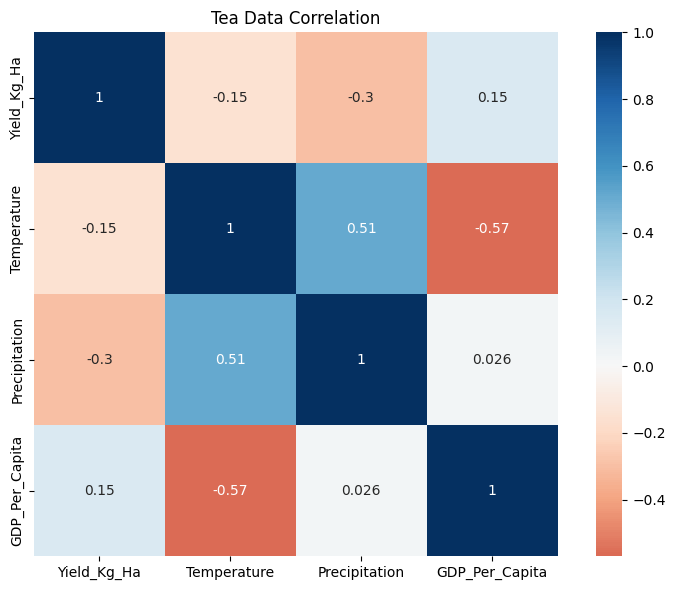

In [32]:
# PResent the correction data in a heatmap
plt.figure(figsize=(8,6))

sns.heatmap(tea_corr
            , annot=True
            , cmap='RdBu'
            , center=0
            ,square=True
            )

plt.title("Tea Data Correlation")
plt.tight_layout()
plt.show()

🔍🕵🏻‍♂️ Lets look at the correlation numbers:
* `Yield` vs `Precipitation`: -0.3 suggests that higher rainfall is associated the lower tea yields. From past experience, we know that both the Camelia Sinensis and the Camelia Assam tea cultivars wants water but also hates to have damp roots. So on surface, this looks credible. 
* `Yield` vs `Temperature`: -0.15 suggests slight tendency for cooler climate for a better tea yield. We know that the best conditions for grow tea are in the higher altitude where the day and night temperature ranges are wider.
* `Temperature` vs `Precipitation`: +0.51 suggest that warmer  countries have more rainfall. It confirms our understanding that tropical regions do have more rainful.
* `Yield` vs `GDP`: +0.15 seems to suggest that wealthier countries tend to have slightly better yields. Perhaps through better investments in farming equipment and management.  However, as the nominal GDP is used here, we will need need to account for inflation and Purchasing power parity.

---

### 2.1.4 🍵 Export to CSV File: Tea 💵 GDP data with 🌡️🌧️ Climate Data

In [17]:
df_main_tea_gdp_climate.to_csv(f'{processed_dir}/df_main_tea_gdp_climate.csv', index=False)
print(f"Exported: {processed_dir}/df_main_tea_gdp_climate.csv")

Exported: ../data/processed/df_main_tea_gdp_climate.csv


---

## 2.2 Merging FAO Coffee Data with GDP and Climate Data

### ☕️ Pivoting coffee FAO data

In [21]:
# create new FAO cofee data such that elements are in columns
df_main_coffee = df_fao_coffee_top15_countries.pivot_table(
    index=["Country_ISO3", "Year"]
    , columns="Element"
    , values="Value"
).reset_index().rename_axis(None, axis=1)

# Add the Crop_Type Column
df_main_coffee["Crop_Type"] = "Coffee"

# Rename the elements column to include their UOM
df_main_coffee = df_main_coffee.rename(columns={
    "Area harvested": "Area_Harvest_Ha"
    , "Production": "Production_Ton"
    , "Yield": "Yield_Kg_Ha"
})

df_main_coffee.head(10)

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type
0,BRA,2000,2267968.0,1903562.0,839.3,Coffee
1,BRA,2001,2336031.0,1819569.0,778.9,Coffee
2,BRA,2002,2370891.0,2610524.0,1101.1,Coffee
3,BRA,2003,2395501.0,1987074.0,829.5,Coffee
4,BRA,2004,2368040.0,2465710.0,1041.2,Coffee
5,BRA,2005,2325920.0,2140169.0,920.1,Coffee
6,BRA,2006,2312157.0,2573368.0,1113.0,Coffee
7,BRA,2007,2264129.0,2249011.0,993.3,Coffee
8,BRA,2008,2222224.0,2796927.0,1258.6,Coffee
9,BRA,2009,2135508.0,2440056.0,1142.6,Coffee


---

### 2.2.1 ☕️ Merging coffee data with 💵 GDP data

In [22]:
df_main_coffee_gdp = pd.merge(
    df_main_coffee
    , df_wb_gdp_long[["Country_ISO3", "Year", "Country_Name", "GDP_Per_Capita" ]]
    , on=["Country_ISO3", "Year"]
    , how="left" # keep all the rows in df_main_tea
    )

df_main_coffee_gdp.head(3)

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type,Country_Name,GDP_Per_Capita
0,BRA,2000,2267968.0,1903562.0,839.3,Coffee,Brazil,3766.547863
1,BRA,2001,2336031.0,1819569.0,778.9,Coffee,Brazil,3176.289751
2,BRA,2002,2370891.0,2610524.0,1101.1,Coffee,Brazil,2855.940171


📌📌 Double check the GDP Figures in the Merged Data

In [23]:
df_results = df_wb_gdp_long[
    (df_wb_gdp_long["Country_ISO3"] == "BRA") & 
    (df_wb_gdp_long["Year"].isin([2000, 2001, 2002]))]

df_results

,economy,Country,Year,GDP_Per_Capita,Country_ISO3,Country_Name
23,BRA,Brazil,2000,3766.547863,BRA,Brazil
49,BRA,Brazil,2001,3176.289751,BRA,Brazil
75,BRA,Brazil,2002,2855.940171,BRA,Brazil


---

### 2.2.2 ☕️ Merging Coffee 💵 GDP data with 🌡️🌧️ Climate Data

In [24]:
df_main_coffee_gdp_climate = pd.merge(
    df_main_coffee_gdp
    , df_crop_country_climate[["Country_ISO3", "Year", "Temperature", "Precipitation", "Crop_Dominance"]]
    , on=["Country_ISO3", "Year"]
    , how="left" # keep all the rows in df_main_tea
    )


df_main_coffee_gdp_climate.head(3)

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type,Country_Name,GDP_Per_Capita,Temperature,Precipitation,Crop_Dominance
0,BRA,2000,2267968.0,1903562.0,839.3,Coffee,Brazil,3766.547863,25.12,1955.68,coffee only
1,BRA,2001,2336031.0,1819569.0,778.9,Coffee,Brazil,3176.289751,25.40,1773.52,coffee only
2,BRA,2002,2370891.0,2610524.0,1101.1,Coffee,Brazil,2855.940171,25.67,1810.10,coffee only


📌📌 Double check the results for **Vietnam** which is a tea and coffee producing country.
* you can see the `Crop_Type` in this tea dataset has the value of `Tea` and the `Crop_Dominance` has the value of `both`

In [25]:
df_results = df_main_coffee_gdp_climate[
    (df_main_coffee_gdp_climate["Country_ISO3"] == "VNM") & 
    (df_main_coffee_gdp_climate["Year"].isin([2000, 2001, 2002]))]

df_results

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type,Country_Name,GDP_Per_Capita,Temperature,Precipitation,Crop_Dominance
349,VNM,2000,476900.0,802500.0,1682.7,Coffee,Vietnam,404.029784,24.50,1722.38,both
350,VNM,2001,473500.0,840600.0,1775.3,Coffee,Vietnam,419.205678,24.71,1929.45,both
351,VNM,2002,492500.0,699500.0,1420.3,Coffee,Vietnam,445.132862,24.81,1890.97,both


📌📌 Double check the climate data for Vietnam

In [26]:
df_results = df_crop_country_climate[
    (df_crop_country_climate["Country_ISO3"] == "VNM") & 
    (df_crop_country_climate["Year"].isin([2000, 2001, 2002]))]

df_results

,Country_ISO3,Year,Temperature,Precipitation,Crop_Dominance
625,VNM,2000,24.50,1722.38,both
626,VNM,2001,24.71,1929.45,both
627,VNM,2002,24.81,1890.97,both


### 2.1.3 ☕️ Correlation Statistics

📌 Lets look at how the variables `Yield_kg_Ha`, `Temperature`, `Precipitation` and nominal `GDP_Per_Capita` are related.

In [27]:
# get the coloumns
df_coffee_corr = df_main_coffee_gdp_climate[["Yield_Kg_Ha", "Temperature", "Precipitation", "GDP_Per_Capita"]]

# calculate the correlation
coffee_corr = df_coffee_corr.corr()

print(coffee_corr)

                Yield_Kg_Ha  Temperature  Precipitation  GDP_Per_Capita
Yield_Kg_Ha        1.000000     0.059683       0.195874        0.083050
Temperature        0.059683     1.000000       0.357828       -0.239234
Precipitation      0.195874     0.357828       1.000000        0.164753
GDP_Per_Capita     0.083050    -0.239234       0.164753        1.000000


🔍🕵🏻‍♂️ Lets look at the correlation numbers for ☕️ coffee:
* `Yield` vs `Precipitation`: 0.20 suggests that higher rainfall is associated the higher coffee yields. 
* `Yield` vs `Temperature`: 0.060 suggests slight tendency for hotter climate for a better coffee yield.
* `Yield` vs `GDP`: 0.08 seems to suggest that wealthier countries tend to have slightly better yields.

---

### 2.2.4 ☕️ Export to CSV File: Coffee 💵 GDP data with 🌡️🌧️ Climate Data

In [24]:
df_main_coffee_gdp_climate.to_csv(f'{processed_dir}/df_main_coffee_gdp_climate.csv', index=False)
print(f"Exported: {processed_dir}/df_main_coffee_gdp_climate.csv")

Exported: ../data/processed/df_main_coffee_gdp_climate.csv


---